# Lab Problem Statement 6 — Statistical Analysis of Palmer Penguins


## 1. Install and load required R packages

Run this cell first. The notebook is designed for **Google Colab with an R runtime**.

In [1]:
# Install packages (run once in a fresh Colab runtime)
install.packages(c("tidyverse", "palmerpenguins", "moments", "car", "effectsize"),
                 repos = "https://cloud.r-project.org")

library(tidyverse)
library(palmerpenguins)
library(moments)
library(car)
library(effectsize)

cat("Packages loaded successfully.\n")


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Packages loaded successfully.


## 2. Load the Palmer Penguins dataset

The `palmerpenguins` package provides the Palmer Penguins dataset. We use the dataset required by the problem statement and keep the important variables for analysis.

In [2]:
# Load dataset
data("penguins")

penguins_data <- penguins %>%
  select(species, island, bill_length_mm, bill_depth_mm,
         flipper_length_mm, body_mass_g, sex)

# Display first observations
head(penguins_data)

# Dataset dimensions
cat("Rows:", nrow(penguins_data), "\n")
cat("Columns:", ncol(penguins_data), "\n")

# Structure
str(penguins_data)


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
Adelie,Torgersen,39.1,18.7,181,3750,male
Adelie,Torgersen,39.5,17.4,186,3800,female
Adelie,Torgersen,40.3,18.0,195,3250,female
Adelie,Torgersen,NA,NA,NA,NA,NA
Adelie,Torgersen,36.7,19.3,193,3450,female
Adelie,Torgersen,39.3,20.6,190,3650,male


Rows: 344 
Columns: 7 
tibble [344 × 7] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...


## 3. Data cleaning and missing-value check

Some observations have missing values, particularly for sex and some measurements. For each statistical test, we will use the variables required for that analysis and remove only rows missing those variables.

In [3]:
# Missing values by variable
colSums(is.na(penguins_data))

# Species counts
table(penguins_data$species)

# Sex counts
table(penguins_data$sex, useNA = "ifany")


species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex 
                2                 2                11


   Adelie Chinstrap    Gentoo 
      152        68       124 


female   male   <NA> 
   165    168     11 

# Part A — Descriptive Statistical Analysis

## 4. Descriptive statistics of body mass

Required measures:
- Mean
- Median
- Minimum and maximum
- Variance
- Standard deviation
- First and third quartiles
- IQR
- Skewness
- Kurtosis

Statistics are also calculated separately for each species.

In [4]:
# Overall body-mass descriptive statistics
body_mass <- penguins_data$body_mass_g
body_mass <- body_mass[!is.na(body_mass)]

overall_stats <- tibble(
  Measure = c("Mean", "Median", "Minimum", "Maximum", "Variance",
              "Standard Deviation", "Q1", "Q3", "IQR",
              "Skewness", "Kurtosis"),
  Value = c(
    mean(body_mass),
    median(body_mass),
    min(body_mass),
    max(body_mass),
    var(body_mass),
    sd(body_mass),
    quantile(body_mass, 0.25),
    quantile(body_mass, 0.75),
    IQR(body_mass),
    skewness(body_mass),
    kurtosis(body_mass)
  )
)

overall_stats


Measure,Value
<chr>,<dbl>
Mean,4.201754e+03
Median,4.050000e+03
Minimum,2.700000e+03
Maximum,6.300000e+03
Variance,6.431311e+05
Standard Deviation,8.019545e+02
Q1,3.550000e+03
Q3,4.750000e+03
IQR,1.200000e+03


In [5]:
# Species-wise descriptive statistics
species_stats <- penguins_data %>%
  group_by(species) %>%
  summarise(
    N = sum(!is.na(body_mass_g)),
    Mean = mean(body_mass_g, na.rm = TRUE),
    Median = median(body_mass_g, na.rm = TRUE),
    Minimum = min(body_mass_g, na.rm = TRUE),
    Maximum = max(body_mass_g, na.rm = TRUE),
    Variance = var(body_mass_g, na.rm = TRUE),
    SD = sd(body_mass_g, na.rm = TRUE),
    Q1 = quantile(body_mass_g, 0.25, na.rm = TRUE),
    Q3 = quantile(body_mass_g, 0.75, na.rm = TRUE),
    IQR = IQR(body_mass_g, na.rm = TRUE),
    Skewness = skewness(body_mass_g, na.rm = TRUE),
    Kurtosis = kurtosis(body_mass_g, na.rm = TRUE),
    .groups = "drop"
  )

species_stats


species,N,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,151,3700.662,3700,2850,4775,210282.9,458.5661,3350.0,4000,650.0,0.28249381,2.405611
Chinstrap,68,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.24194125,3.463681
Gentoo,123,5076.016,5000,3950,6300,254133.2,504.1162,4700.0,5500,800.0,0.06878276,2.257871


## 5. Visualizations — Body mass distribution

### Histogram

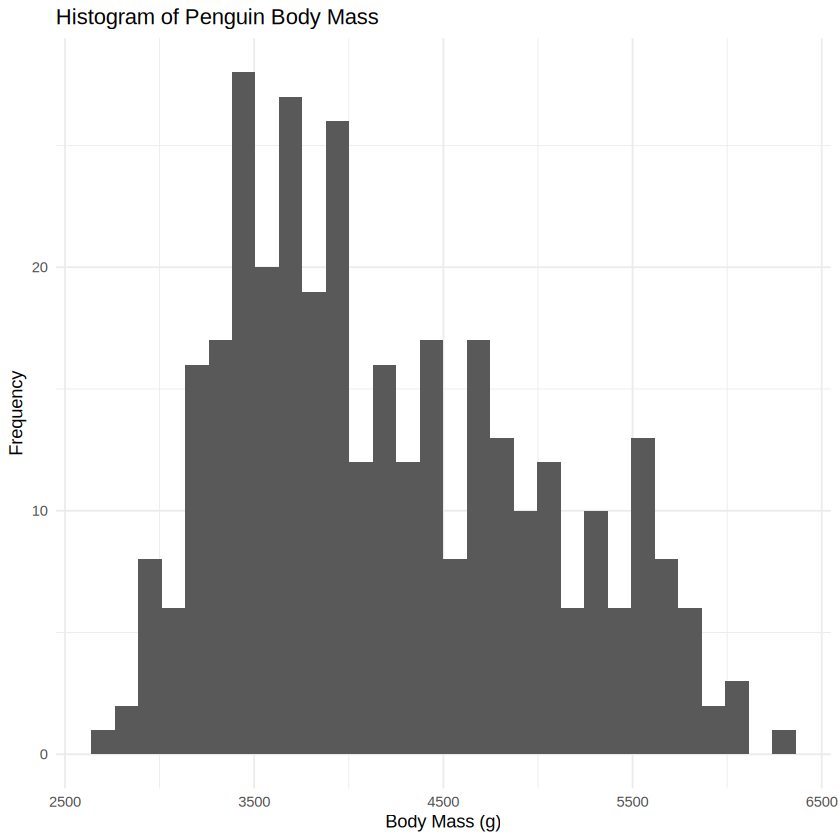

In [6]:
ggplot(penguins_data, aes(x = body_mass_g)) +
  geom_histogram(bins = 30, na.rm = TRUE) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()


### Species-wise boxplot

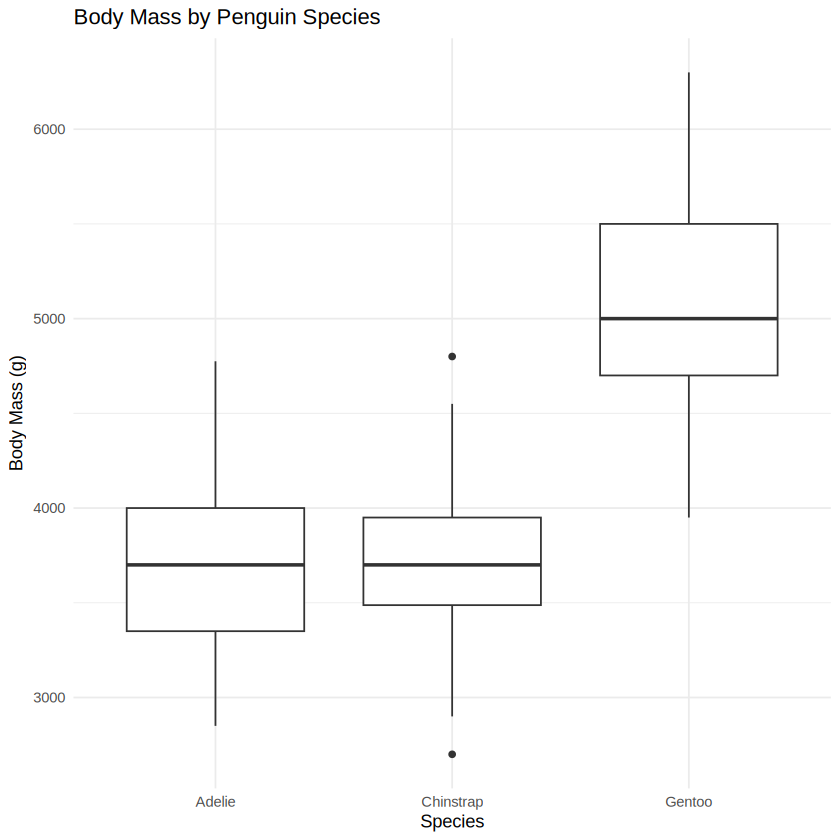

In [7]:
ggplot(penguins_data, aes(x = species, y = body_mass_g)) +
  geom_boxplot(na.rm = TRUE) +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()


### Density plot

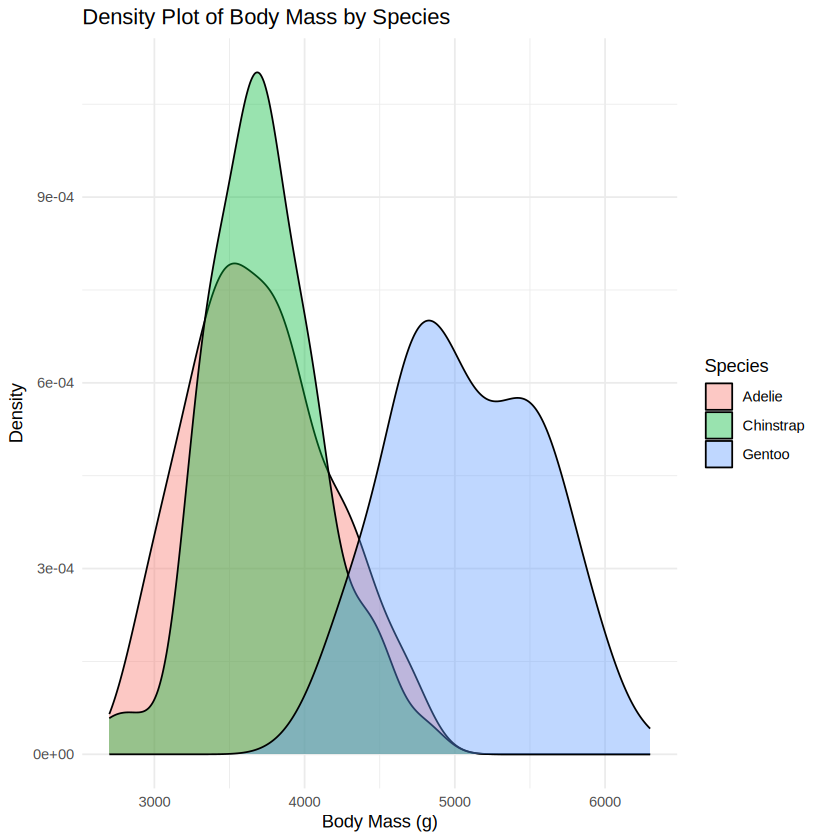

In [8]:
ggplot(penguins_data, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4, na.rm = TRUE) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()


# Part B — Hypothesis Testing

## 6. Male vs Female Body Mass

### Hypotheses

- **H0:** The mean body mass of male penguins is equal to the mean body mass of female penguins.
- **H1:** The mean body mass of male penguins is different from the mean body mass of female penguins.

We first check normality using Shapiro-Wilk tests and QQ-plots, then perform an independent two-sample Welch t-test.

In [9]:
sex_data <- penguins_data %>%
  filter(!is.na(body_mass_g), !is.na(sex)) %>%
  droplevels()

# Summary by sex
sex_data %>%
  group_by(sex) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    SD = sd(body_mass_g),
    .groups = "drop"
  )


sex,N,Mean,SD
<fct>,<int>,<dbl>,<dbl>
female,165,3862.273,666.1720
male,168,4545.685,787.6289


### Shapiro-Wilk normality tests

In [10]:
shapiro_male <- shapiro.test(sex_data$body_mass_g[sex_data$sex == "male"])
shapiro_female <- shapiro.test(sex_data$body_mass_g[sex_data$sex == "female"])

shapiro_male
shapiro_female



	Shapiro-Wilk normality test

data:  sex_data$body_mass_g[sex_data$sex == "male"]
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  sex_data$body_mass_g[sex_data$sex == "female"]
W = 0.91931, p-value = 6.155e-08


### QQ-plots

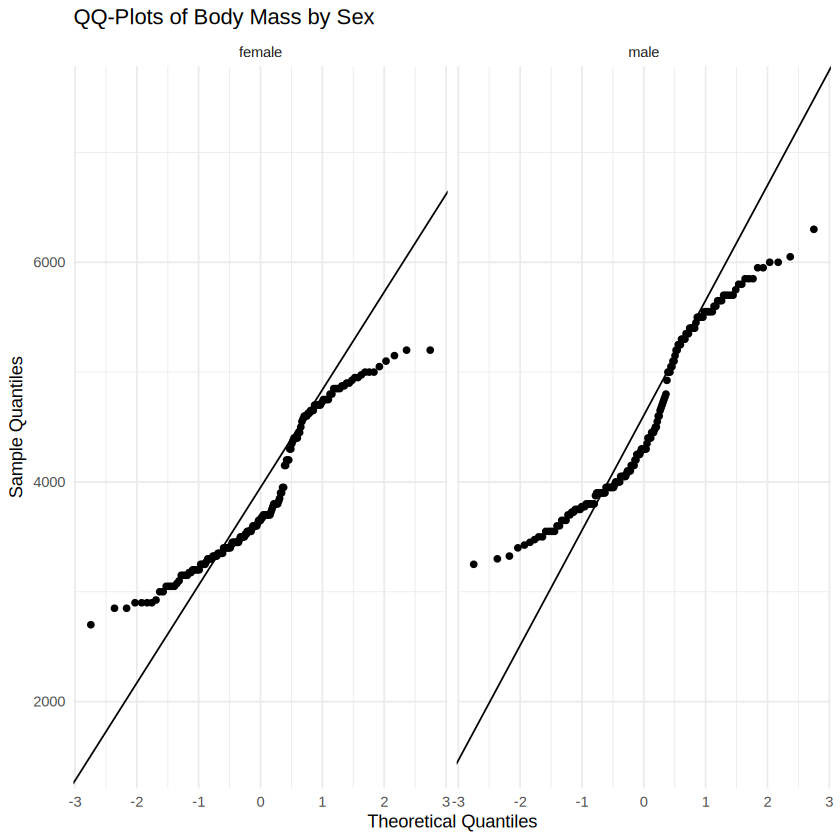

In [11]:
ggplot(sex_data, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~sex) +
  labs(
    title = "QQ-Plots of Body Mass by Sex",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()


### Independent two-sample Welch t-test

Welch's t-test is used because it does not require equal population variances.

In [12]:
t_test_result <- t.test(
  body_mass_g ~ sex,
  data = sex_data,
  var.equal = FALSE,
  conf.level = 0.95
)

t_test_result



	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


### Cohen's d effect size

In [13]:
cohen_d_result <- cohens_d(
  body_mass_g ~ sex,
  data = sex_data,
  pooled_sd = TRUE,
  ci = 0.95
)

cohen_d_result


Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


### Interpretation helper

Use the printed p-value, confidence interval and Cohen's d above. A p-value below 0.05 indicates statistically significant evidence against H0. If the 95% confidence interval for the mean difference does not include zero, that also supports a significant difference. Cohen's d describes the magnitude of the difference.

In [14]:
# Extract and print a concise interpretation
p_val <- t_test_result$p.value
ci_low <- t_test_result$conf.int[1]
ci_high <- t_test_result$conf.int[2]

cat("p-value =", p_val, "\n")
cat("95% CI for mean difference = [", ci_low, ",", ci_high, "]\n")

if (p_val < 0.05) {
  cat("Conclusion: Reject H0. Male and female penguins have significantly different mean body masses.\n")
} else {
  cat("Conclusion: Fail to reject H0. There is not enough evidence of a difference in mean body mass.\n")
}


p-value = 4.793891e-16 
95% CI for mean difference = [ -840.5783 , -526.2453 ]
Conclusion: Reject H0. Male and female penguins have significantly different mean body masses.


### Sex-wise boxplot

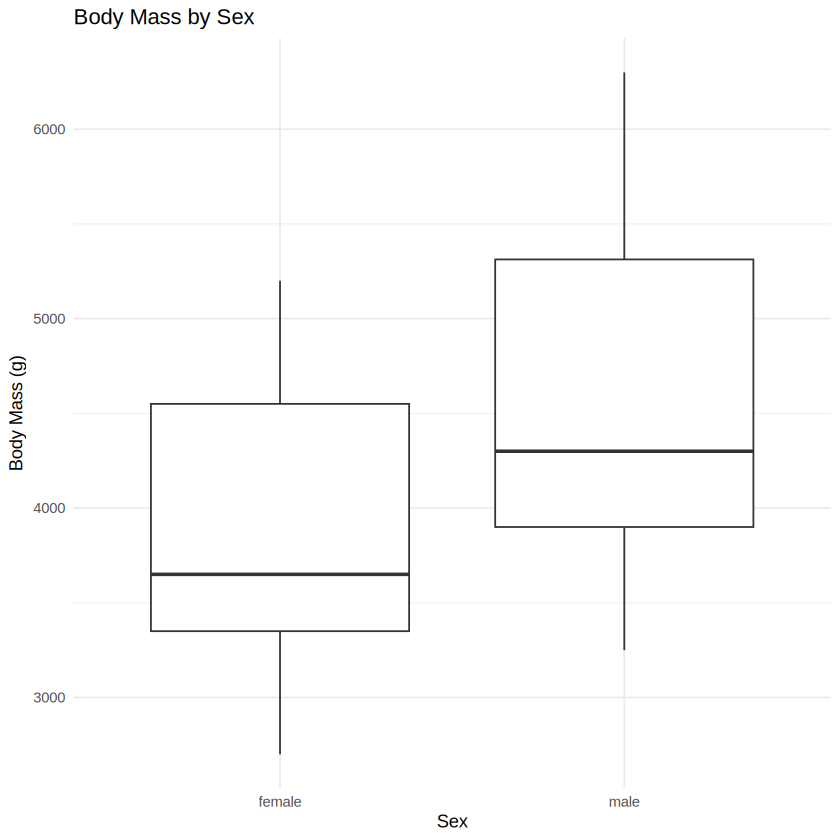

In [15]:
ggplot(sex_data, aes(x = sex, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()


# Part C — One-Way ANOVA

## 7. Body mass across the three species

Model:

`body_mass_g ~ species`

Before ANOVA we examine distributions, normality and homogeneity of variance.

In [16]:
species_body <- penguins_data %>%
  filter(!is.na(body_mass_g), !is.na(species)) %>%
  droplevels()

# Species-wise sample sizes and summary
species_body %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    SD = sd(body_mass_g),
    .groups = "drop"
  )


species,N,Mean,SD
<fct>,<int>,<dbl>,<dbl>
Adelie,151,3700.662,458.5661
Chinstrap,68,3733.088,384.3351
Gentoo,123,5076.016,504.1162


### QQ-plots by species

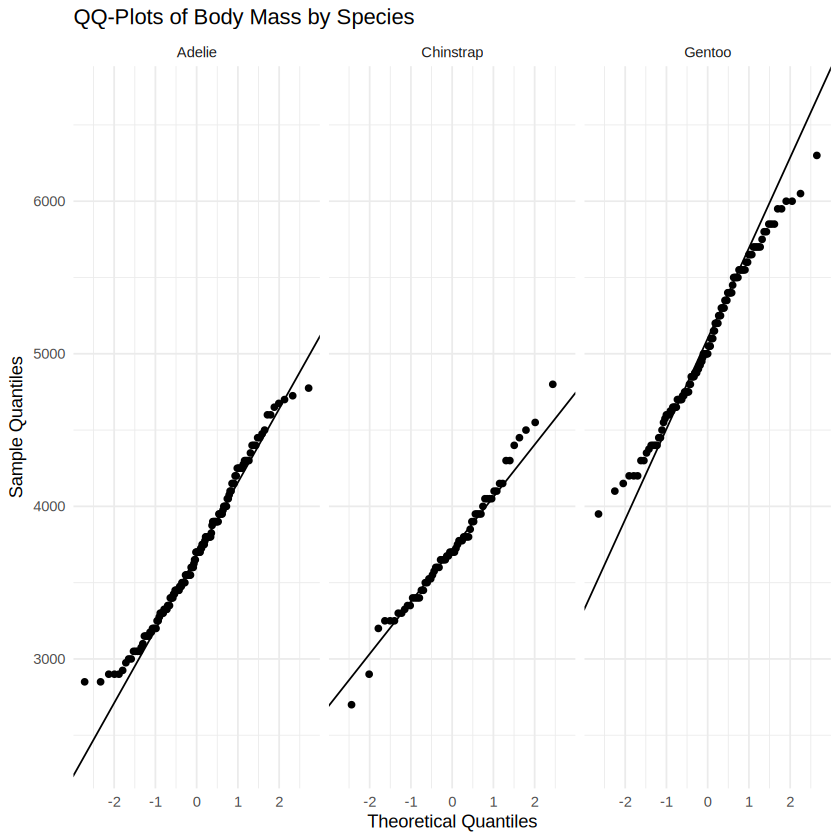

In [17]:
ggplot(species_body, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(
    title = "QQ-Plots of Body Mass by Species",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()


### Shapiro-Wilk tests by species

In [18]:
shapiro_by_species <- species_body %>%
  group_by(species) %>%
  summarise(
    Shapiro_W = unname(shapiro.test(body_mass_g)$statistic),
    p_value = shapiro.test(body_mass_g)$p.value,
    .groups = "drop"
  )

shapiro_by_species


species,Shapiro_W,p_value
<fct>,<dbl>,<dbl>
Adelie,0.9807079,0.03239702
Chinstrap,0.9844938,0.56050824
Gentoo,0.9859276,0.23361649


### Levene's test for homogeneity of variance

In [19]:
levene_result <- leveneTest(body_mass_g ~ species, data = species_body)
levene_result


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.120251,0.006445083
,339,NA,NA


### One-way ANOVA

In [20]:
anova_oneway <- aov(body_mass_g ~ species, data = species_body)
summary(anova_oneway)


             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Extract F-statistic, degrees of freedom and p-value

In [21]:
anova_table <- summary(anova_oneway)[[1]]

F_value <- anova_table["species", "F value"]
df_between <- anova_table["species", "Df"]
df_within <- anova_table["Residuals", "Df"]
p_anova <- anova_table["species", "Pr(>F)"]

cat("F-statistic:", F_value, "\n")
cat("Degrees of freedom:", df_between, "and", df_within, "\n")
cat("p-value:", p_anova, "\n")

if (p_anova < 0.05) {
  cat("Conclusion: Reject H0. Mean body mass differs significantly among species.\n")
} else {
  cat("Conclusion: Fail to reject H0. No significant difference among species means was detected.\n")
}


F-statistic: 343.6263 
Degrees of freedom: 2 and 339 
p-value: 2.892368e-82 
Conclusion: Reject H0. Mean body mass differs significantly among species.


### Tukey HSD post-hoc test

If ANOVA is significant, Tukey's HSD identifies which pairs of species differ.

In [22]:
tukey_result <- TukeyHSD(anova_oneway)
tukey_result


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = species_body)

$species
                       diff       lwr       upr     p adj
Chinstrap-Adelie   32.42598 -126.5002  191.3522 0.8806666
Gentoo-Adelie    1375.35401 1243.1786 1507.5294 0.0000000
Gentoo-Chinstrap 1342.92802 1178.4810 1507.3750 0.0000000


### Visualize Tukey group differences

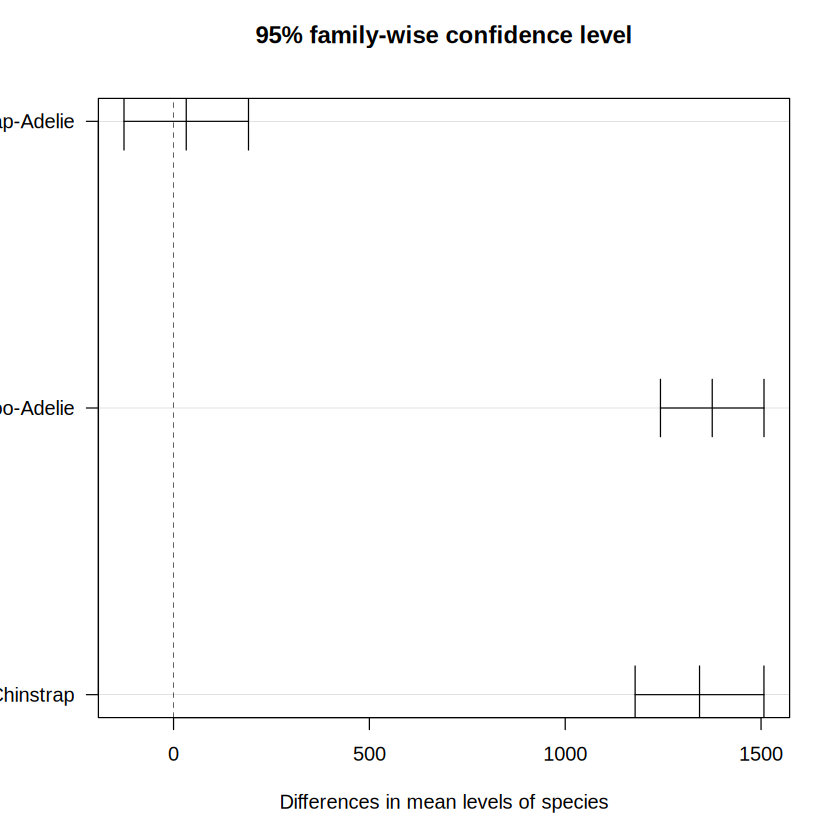

In [23]:
plot(tukey_result, las = 1)


# Part D — Non-Parametric Analysis

## 8. Kruskal-Wallis test

If ANOVA assumptions are substantially violated, Kruskal-Wallis provides a non-parametric alternative for comparing the species groups.

In [24]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = species_body)
kruskal_result



	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16


In [25]:
cat("One-way ANOVA p-value:", p_anova, "\n")
cat("Kruskal-Wallis p-value:", kruskal_result$p.value, "\n")

if (p_anova < 0.05 && kruskal_result$p.value < 0.05) {
  cat("Comparison: Both methods indicate a statistically significant difference among species.\n")
} else if (p_anova >= 0.05 && kruskal_result$p.value >= 0.05) {
  cat("Comparison: Both methods do not indicate a statistically significant species difference.\n")
} else {
  cat("Comparison: The two methods give different significance conclusions; inspect assumptions and group distributions carefully.\n")
}


One-way ANOVA p-value: 2.892368e-82 
Kruskal-Wallis p-value: 5.609512e-48 
Comparison: Both methods indicate a statistically significant difference among species.


# Part E — Two-Way ANOVA

## 9. Simultaneous effect of species and sex

Model:

`body_mass_g ~ species * sex`

This tests:
- Main effect of species
- Main effect of sex
- Species × sex interaction

In [26]:
two_way_data <- penguins_data %>%
  filter(!is.na(body_mass_g), !is.na(species), !is.na(sex)) %>%
  droplevels()

two_way_anova <- aov(body_mass_g ~ species * sex, data = two_way_data)
summary(two_way_anova)


             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Two-way ANOVA interpretation

In [27]:
two_way_table <- summary(two_way_anova)[[1]]
two_way_table

cat("\nInterpretation:\n")
cat("- Species effect p-value:", two_way_table["species", "Pr(>F)"], "\n")
cat("- Sex effect p-value:", two_way_table["sex", "Pr(>F)"], "\n")
cat("- Species × Sex interaction p-value:", two_way_table["species:sex", "Pr(>F)"], "\n")


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
species,2,145190219,72595109.56,758.358072,1.540207e-123
sex,1,37090262,37090261.78,387.459976,1.902273e-57
species:sex,2,1676557,838278.37,8.756997,1.973489e-04
Residuals,327,31302628,95726.69,NA,NA



Interpretation:
- Species effect p-value: NA 
- Sex effect p-value: 1.902273e-57 
- Species × Sex interaction p-value: 0.0001973489 


### Interaction plot

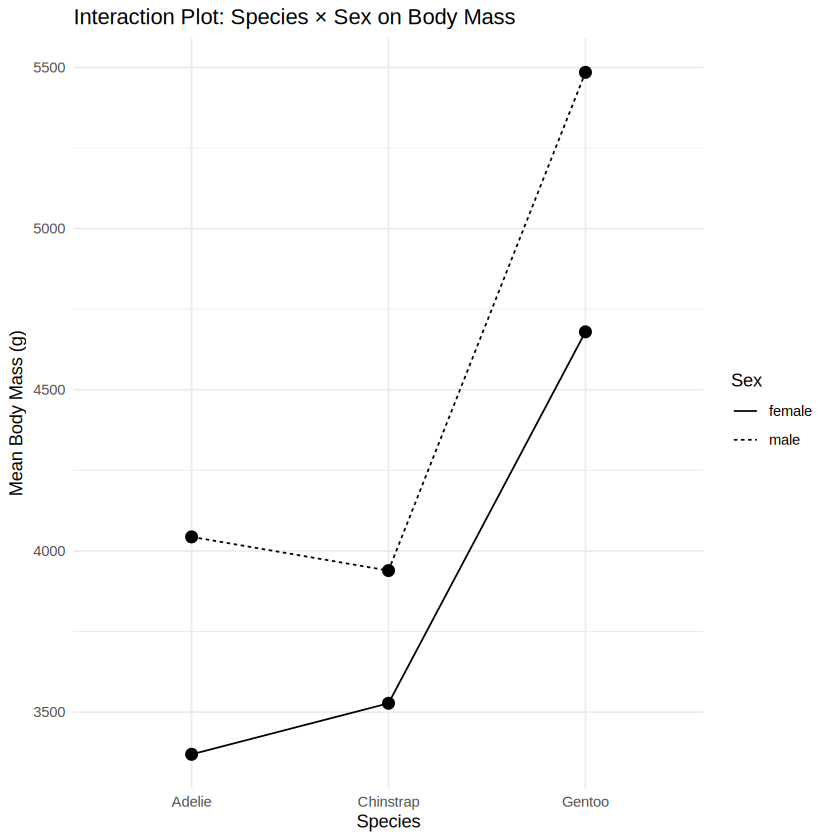

In [28]:
ggplot(two_way_data,
       aes(x = species, y = body_mass_g, group = sex, linetype = sex)) +
  stat_summary(fun = mean, geom = "point", size = 3) +
  stat_summary(fun = mean, geom = "line") +
  labs(
    title = "Interaction Plot: Species × Sex on Body Mass",
    x = "Species",
    y = "Mean Body Mass (g)",
    linetype = "Sex"
  ) +
  theme_minimal()


# Part F — Additional Analysis

## 10. Flipper length across species

The problem statement asks to repeat an appropriate part of the analysis using `flipper_length_mm` and investigate whether flipper length differs among the three species.

In [29]:
flipper_data <- penguins_data %>%
  filter(!is.na(flipper_length_mm), !is.na(species)) %>%
  droplevels()

# Descriptive summary
flipper_summary <- flipper_data %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Min = min(flipper_length_mm),
    Max = max(flipper_length_mm),
    .groups = "drop"
  )

flipper_summary


species,N,Mean,Median,SD,Min,Max
<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
Adelie,151,189.9536,190,6.539457,172,210
Chinstrap,68,195.8235,196,7.131894,178,212
Gentoo,123,217.1870,216,6.484976,203,231


### Flipper-length boxplot

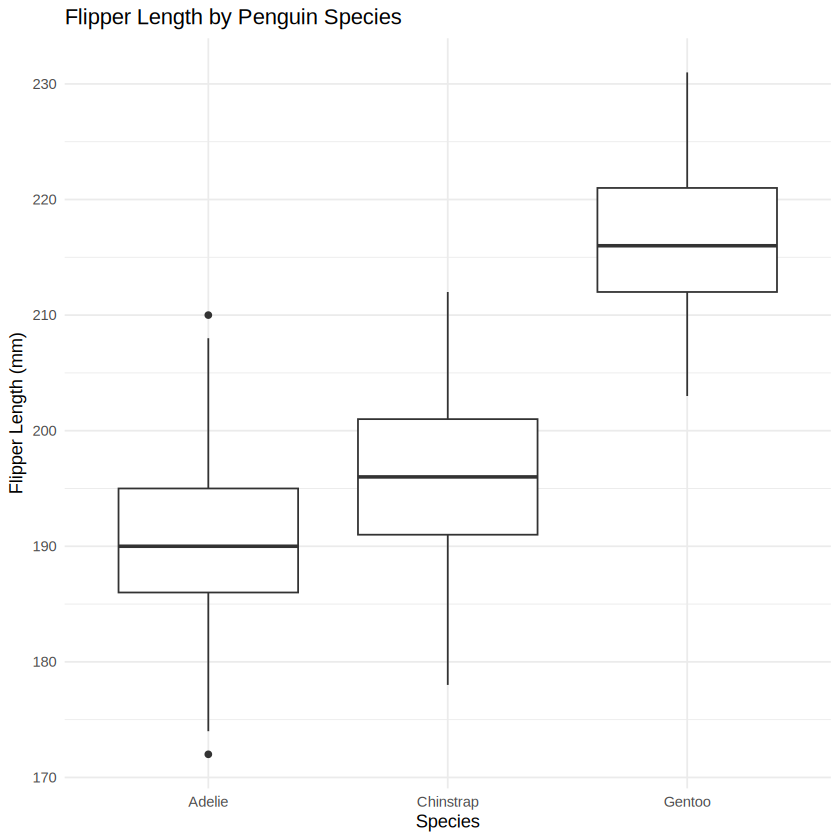

In [30]:
ggplot(flipper_data, aes(x = species, y = flipper_length_mm)) +
  geom_boxplot() +
  labs(
    title = "Flipper Length by Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()


### Flipper-length ANOVA

In [31]:
flipper_anova <- aov(flipper_length_mm ~ species, data = flipper_data)
summary(flipper_anova)


             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Flipper-length Kruskal-Wallis test

In [32]:
flipper_kw <- kruskal.test(flipper_length_mm ~ species, data = flipper_data)
flipper_kw



	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 244.89, df = 2, p-value < 2.2e-16


### Tukey HSD for flipper length

In [33]:
TukeyHSD(flipper_anova)


  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = flipper_data)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


# Part G — Required Group Comparison Visualizations

## 11. Species-wise body mass comparison

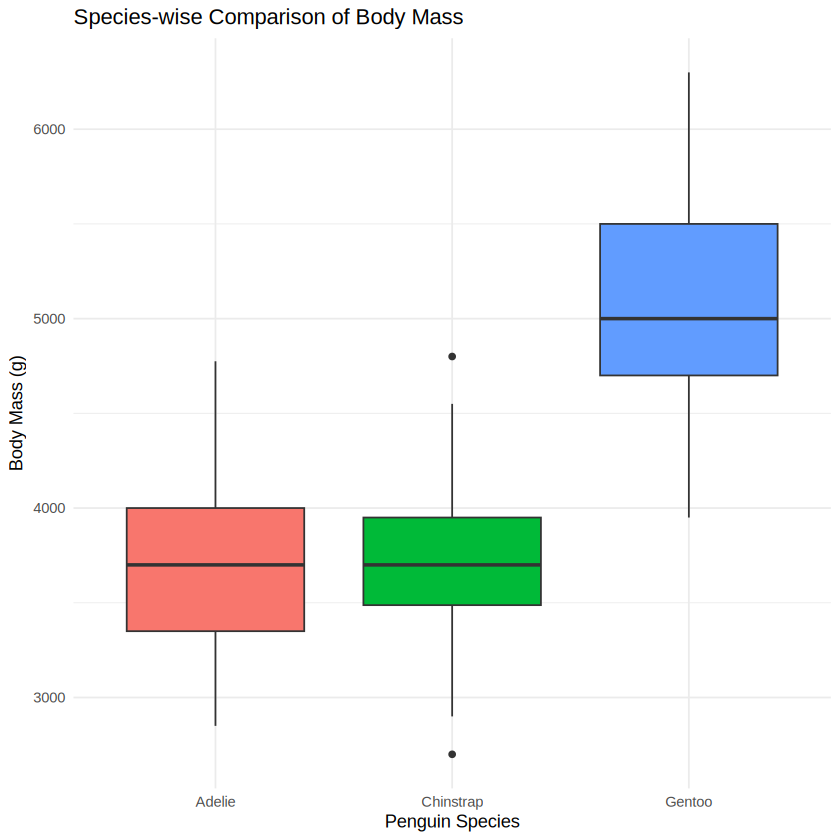

In [34]:
ggplot(species_body, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot(na.rm = TRUE) +
  labs(
    title = "Species-wise Comparison of Body Mass",
    x = "Penguin Species",
    y = "Body Mass (g)",
    fill = "Species"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


## 12. Species-wise flipper-length comparison

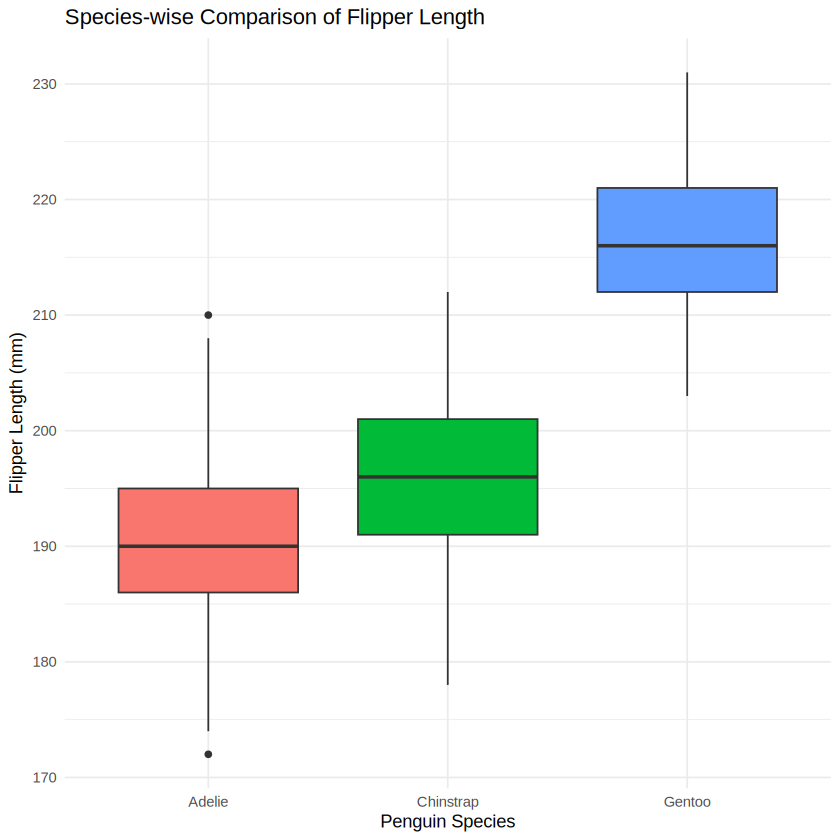

In [35]:
ggplot(flipper_data, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot(na.rm = TRUE) +
  labs(
    title = "Species-wise Comparison of Flipper Length",
    x = "Penguin Species",
    y = "Flipper Length (mm)",
    fill = "Species"
  ) +
  theme_minimal() +
  theme(legend.position = "none")


# Part H — Final Summary of Statistical Results

The following cell produces a compact result summary that can be included in the practical submission.

In [36]:
cat("========== FINAL STATISTICAL SUMMARY ==========\n\n")

cat("1. Male vs Female Body Mass\n")
cat("   Welch t-test p-value:", t_test_result$p.value, "\n")
cat("   95% CI:", t_test_result$conf.int[1], "to", t_test_result$conf.int[2], "\n")
cat("   Cohen's d:\n")
print(cohen_d_result)

cat("\n2. One-Way ANOVA: Body Mass ~ Species\n")
cat("   F-statistic:", F_value, "\n")
cat("   df:", df_between, ",", df_within, "\n")
cat("   p-value:", p_anova, "\n")

cat("\n3. Kruskal-Wallis: Body Mass ~ Species\n")
cat("   Chi-squared:", unname(kruskal_result$statistic), "\n")
cat("   df:", unname(kruskal_result$parameter), "\n")
cat("   p-value:", kruskal_result$p.value, "\n")

cat("\n4. Two-Way ANOVA: Body Mass ~ Species * Sex\n")
cat("   Species p-value:", two_way_table["species", "Pr(>F)"], "\n")
cat("   Sex p-value:", two_way_table["sex", "Pr(>F)"], "\n")
cat("   Interaction p-value:", two_way_table["species:sex", "Pr(>F)"], "\n")

cat("\n5. Flipper Length ANOVA\n")
cat("   p-value:", summary(flipper_anova)[[1]]["species", "Pr(>F)"], "\n")

cat("\n6. Flipper Length Kruskal-Wallis\n")
cat("   p-value:", flipper_kw$p.value, "\n")


========== FINAL STATISTICAL SUMMARY ==========

1. Male vs Female Body Mass
   Welch t-test p-value: 4.793891e-16 
   95% CI: -840.5783 to -526.2453 
   Cohen's d:
Cohen's d |         95% CI
--------------------------
-0.94     | [-1.16, -0.71]

- Estimated using pooled SD.
2. One-Way ANOVA: Body Mass ~ Species
   F-statistic: 343.6263 
   df: 2 , 339 
   p-value: 2.892368e-82 

3. Kruskal-Wallis: Body Mass ~ Species
   Chi-squared: 217.5992 
   df: 2 
   p-value: 5.609512e-48 

4. Two-Way ANOVA: Body Mass ~ Species * Sex
   Species p-value: NA 
   Sex p-value: 1.902273e-57 
   Interaction p-value: 0.0001973489 

5. Flipper Length ANOVA
   p-value: 1.35171e-111 

6. Flipper Length Kruskal-Wallis
   p-value: 6.648053e-54 
